# Conflict-Induced Food Crisis Prediction
## Task 4: Final Evaluation, SHAP Explainability & Africa Risk Map  v1.0

**Input**  : `best_model.pkl`, `X_test.csv`, `y_test.csv`, `task3_results.json`
**Output** : `final_evaluation.png`, `shap_*.png`, `country_performance.png`,
             `test_results.json`, `africa_crisis_map.html`

---
### Notebook Structure

| Step | Section |
|---|---|
| 1  | Setup (install shap, folium) |
| 1b | Restore from Google Drive |
| 2  | Load model + unseal test set |
| 3  | Final test-set evaluation |
| 4  | Confusion matrices + PR curves |
| 5  | Country-level performance |
| 6  | SHAP global beeswarm |
| 7  | SHAP waterfall — high-risk case |
| 8  | SHAP waterfall — blind-spot FN (Sudan/Chad) |
| 9  | Test set error analysis |
| 10 | Africa Crisis Map (Folium interactive HTML) |
| 11 | Save + Drive backup |


---
## Step 1 — Setup

In [13]:
import subprocess, sys, os

def install(pkg):
    try: __import__(pkg.split('[')[0].replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['xgboost', 'scikit-learn', 'matplotlib', 'seaborn', 'joblib', 'shap', 'folium']:
    install(pkg)

import json, warnings, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import folium
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
DATA_DIR  = Path('/content/crisis_outputs') if IN_COLAB else \
            Path(r'D:\Project\10academy\Conflict-Induced Food Crisis Prediction\data')
OUT_DIR   = DATA_DIR
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Data dir    : {DATA_DIR}')
print(f'SHAP        : {shap.__version__}')
print(f'Folium      : {folium.__version__}')
print('\n✅ Setup complete.')


Installing scikit-learn...
Environment : Google Colab
Data dir    : /content/crisis_outputs
SHAP        : 0.51.0
Folium      : 0.20.0

✅ Setup complete.


---
## Step 1b — Restore from Google Drive

In [ ]:
import shutil

if IN_COLAB:
    try:
        from google.colab import drive
        if not Path('/content/drive/MyDrive').exists():
            drive.mount('/content/drive')
        print('✅ Drive mounted.')
    except Exception as e:
        print(f'Drive error: {e}')

BACKUP = Path('/content/drive/MyDrive/crisis_outputs_backup')
DEST   = Path('/content/crisis_outputs')
DEST.mkdir(parents=True, exist_ok=True)

if not IN_COLAB:
    print('Local — restore skipped.')
elif not BACKUP.exists():
    print(f'Backup not found at {BACKUP}')
else:
    n = 0
    for src in BACKUP.rglob('*'):
        if src.is_file():
            dst = DEST / src.relative_to(BACKUP)
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(str(src), str(dst))
            n += 1
    print(f'Restored {n} files.')

required = ['best_model.pkl', 'X_test.csv', 'y_test.csv', 'task3_results.json',
            'X_val.csv', 'y_val.csv', 'features_engineered.csv']
print()
for f in required:
    p = DEST / f
    status = f'{p.stat().st_size/1024:.1f} KB' if p.exists() else 'MISSING'
    mark   = '✅' if p.exists() else '❌'
    print(f'  {mark} {f:<35} {status}')


Mounted at /content/drive
✅ Drive mounted.
Restored 66 files.

  ✅ best_model.pkl                      693.3 KB
  ✅ X_test.csv                          1289.3 KB
  ✅ y_test.csv                          16.5 KB
  ✅ task3_results.json                  2.7 KB
  ✅ X_val.csv                           621.3 KB
  ✅ y_val.csv                           7.6 KB
  ✅ features_engineered.csv             5791.2 KB


---
## Step 2 — Load Model & Unseal Test Set

In [ ]:
model = joblib.load(DATA_DIR / 'best_model.pkl')
with open(DATA_DIR / 'task3_results.json') as f:
    t3 = json.load(f)

OPT_THRESHOLD = t3['opt_threshold']
HR_THRESHOLD  = t3.get('hr_threshold', 0.077)
BEST_PARAMS   = t3['best_params']

X_val = pd.read_csv(DATA_DIR / 'X_val.csv')
y_val = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()

print('UNSEALING TEST SET (2024-01 to 2026-01)')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()
FEATURE_COLS = X_test.columns.tolist()

val_medians = X_val.median()
X_val  = X_val.fillna(val_medians)
X_test = X_test.fillna(val_medians)

print(f'Test  : {len(X_test):,} rows  crisis={y_test.mean()*100:.1f}%')
print(f'Val   : {len(X_val):,} rows  crisis={y_val.mean()*100:.1f}%  (reference)')
print(f'Model : best_iteration={model.best_iteration}')
print(f'Params: {BEST_PARAMS}')
print(f'F1-threshold={OPT_THRESHOLD}  |  HR-threshold={HR_THRESHOLD}')
print('\n✅ Ready for evaluation.')


UNSEALING TEST SET (2024-01 to 2026-01)
Test  : 8,459 rows  crisis=52.7%
Val   : 3,892 rows  crisis=48.8%  (reference)
Model : best_iteration=499
Params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 5}
F1-threshold=0.497  |  HR-threshold=0.077

✅ Ready for evaluation.


---
## Step 3 — Final Test Set Evaluation (Unsealed)

In [14]:
test_proba    = model.predict_proba(X_test)[:, 1]
val_proba     = model.predict_proba(X_val)[:, 1]
test_pred_opt = (test_proba >= OPT_THRESHOLD).astype(int)
test_pred_hr  = (test_proba >= HR_THRESHOLD).astype(int)

print('=' * 60)
print('FINAL TEST SET EVALUATION (2024-01 to 2026-01)')
print('=' * 60)

print(f'\n--- F1-Optimal Threshold ({OPT_THRESHOLD}) ---')
print(classification_report(y_test, test_pred_opt,
      target_names=['Safe (0)', 'Crisis (1)'], digits=4))
cm_opt = confusion_matrix(y_test, test_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'FNR={fn/(fn+tp)*100:.1f}%  FPR={fp/(fp+tn)*100:.1f}%')

print(f'\n--- Humanitarian Threshold ({HR_THRESHOLD}) ---')
print(classification_report(y_test, test_pred_hr,
      target_names=['Safe (0)', 'Crisis (1)'], digits=4))
cm_hr = confusion_matrix(y_test, test_pred_hr)
tn2, fp2, fn2, tp2 = cm_hr.ravel()
print(f'TN={tn2:,}  FP={fp2:,}  FN={fn2:,}  TP={tp2:,}')
print(f'FNR={fn2/(fn2+tp2)*100:.1f}%')

roc_auc = roc_auc_score(y_test, test_proba)
pr_auc  = average_precision_score(y_test, test_proba)
print(f'\nROC-AUC = {roc_auc:.4f}  (val={t3["val_metrics"]["roc_auc"]:.4f})')
print(f'PR-AUC  = {pr_auc:.4f}  (val={t3["val_metrics"]["pr_auc"]:.4f})')

test_f1     = f1_score(y_test, test_pred_opt)
val_f1      = t3['val_metrics']['f1']
test_recall = recall_score(y_test, test_pred_opt)
val_recall  = t3['val_metrics']['recall']
print('\n=== GENERALIZATION (Val 2023 vs Test 2024-2026) ===')
print(f'{"Metric":<12} {"Val":>10} {"Test":>10} {"Delta":>8}')
print('-' * 42)
for lbl, vv, tv in [('F1', val_f1, test_f1),
                    ('Recall', val_recall, test_recall),
                    ('PR-AUC', t3['val_metrics']['pr_auc'], pr_auc),
                    ('ROC-AUC', t3['val_metrics']['roc_auc'], roc_auc)]:
    print(f'{lbl:<12} {vv:>10.4f} {tv:>10.4f} {tv-vv:>+8.4f}')


FINAL TEST SET EVALUATION (2024-01 to 2026-01)

--- F1-Optimal Threshold (0.497) ---
              precision    recall  f1-score   support

    Safe (0)     0.9825    0.9988    0.9906      4001
  Crisis (1)     0.9989    0.9841    0.9914      4458

    accuracy                         0.9910      8459
   macro avg     0.9907    0.9914    0.9910      8459
weighted avg     0.9911    0.9910    0.9910      8459

TN=3,996  FP=5  FN=71  TP=4,387
FNR=1.6%  FPR=0.1%

--- Humanitarian Threshold (0.077) ---
              precision    recall  f1-score   support

    Safe (0)     0.9869    0.9030    0.9431      4001
  Crisis (1)     0.9191    0.9892    0.9529      4458

    accuracy                         0.9485      8459
   macro avg     0.9530    0.9461    0.9480      8459
weighted avg     0.9512    0.9485    0.9483      8459

TN=3,613  FP=388  FN=48  TP=4,410
FNR=1.1%

ROC-AUC = 0.9966  (val=0.9882)
PR-AUC  = 0.9976  (val=0.9890)

=== GENERALIZATION (Val 2023 vs Test 2024-2026) ===
Metric     

---
## Step 4 — Confusion Matrices + PR Curves

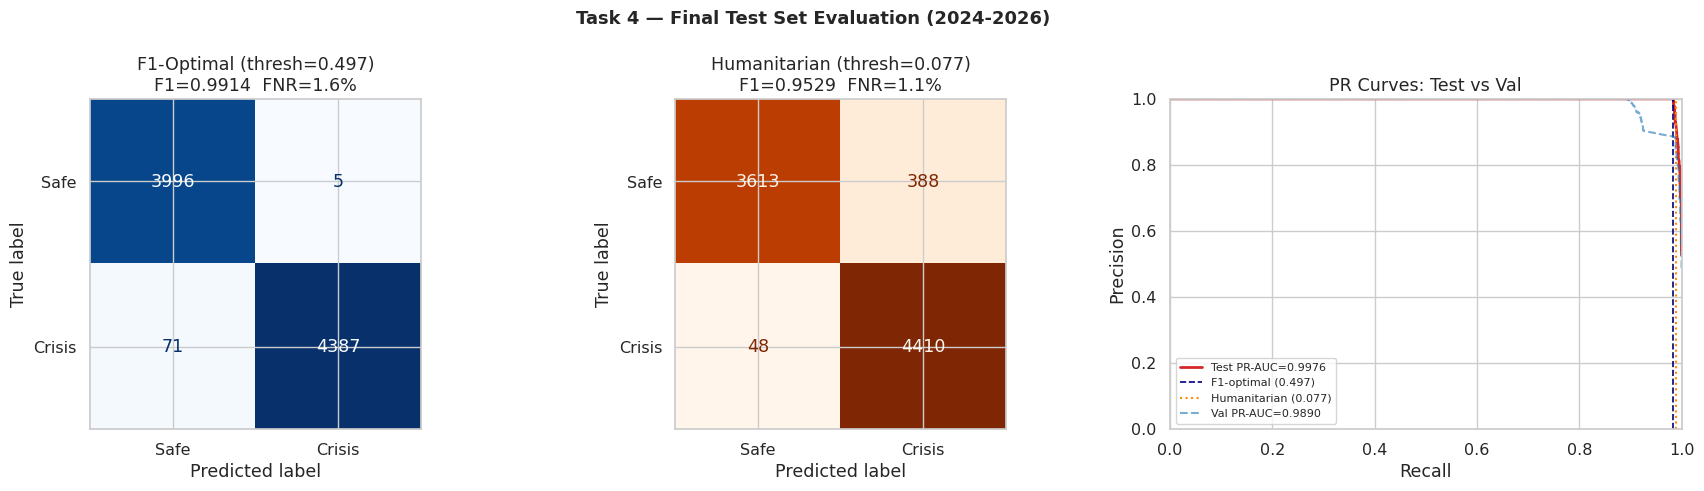

✅ final_evaluation.png saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 4 — Final Test Set Evaluation (2024-2026)', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(cm_opt, display_labels=['Safe','Crisis']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'F1-Optimal (thresh={OPT_THRESHOLD})\n'
                  f'F1={test_f1:.4f}  FNR={fn/(fn+tp)*100:.1f}%')

ConfusionMatrixDisplay(cm_hr, display_labels=['Safe','Crisis']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
hr_f1  = f1_score(y_test, test_pred_hr)
axes[1].set_title(f'Humanitarian (thresh={HR_THRESHOLD})\n'
                  f'F1={hr_f1:.4f}  FNR={fn2/(fn2+tp2)*100:.1f}%')

precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
axes[2].plot(recalls, precisions, color='#d62728', lw=2,
             label=f'Test PR-AUC={pr_auc:.4f}')
axes[2].axvline(recall_score(y_test, test_pred_opt), color='navy',
                ls='--', lw=1.2, label=f'F1-optimal ({OPT_THRESHOLD})')
axes[2].axvline(recall_score(y_test, test_pred_hr), color='darkorange',
                ls=':', lw=1.5, label=f'Humanitarian ({HR_THRESHOLD})')
pv, rv, _ = precision_recall_curve(y_val, val_proba)
axes[2].plot(rv, pv, color='#1f77b4', lw=1.5, ls='--', alpha=0.6,
             label=f'Val PR-AUC={t3["val_metrics"]["pr_auc"]:.4f}')
axes[2].set(title='PR Curves: Test vs Val', xlabel='Recall',
            ylabel='Precision', xlim=[0,1], ylim=[0,1])
axes[2].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(OUT_DIR / 'final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ final_evaluation.png saved.')


---
## Step 5 — Country-Level Performance

Country Performance (Test 2024-2026):
Country                                  F1   Recall     FNR   PR-AUC
----------------------------------------------------------------------
Sudan                                1.0000   1.0000    0.0%   1.0000
Somalia                              0.9951   0.9902    1.0%   0.9994
Burkina Faso                         0.9897   0.9796    2.0%   0.9951
Cameroon                             0.9831   0.9667    3.3%   0.9933
Chad                                 0.9814   0.9635    3.7%   0.9924
Niger                                0.9785   0.9661    3.4%   0.9946
Ethiopia                             0.9745   0.9502    5.0%   0.9900
Nigeria                              0.9690   0.9481    5.2%   0.9809
Mozambique                           0.9659   0.9340    6.6%   0.9969
Kenya                                0.9648   0.9412    5.9%   0.9717
Mali                                 0.9250   0.8810   11.9%   0.9309


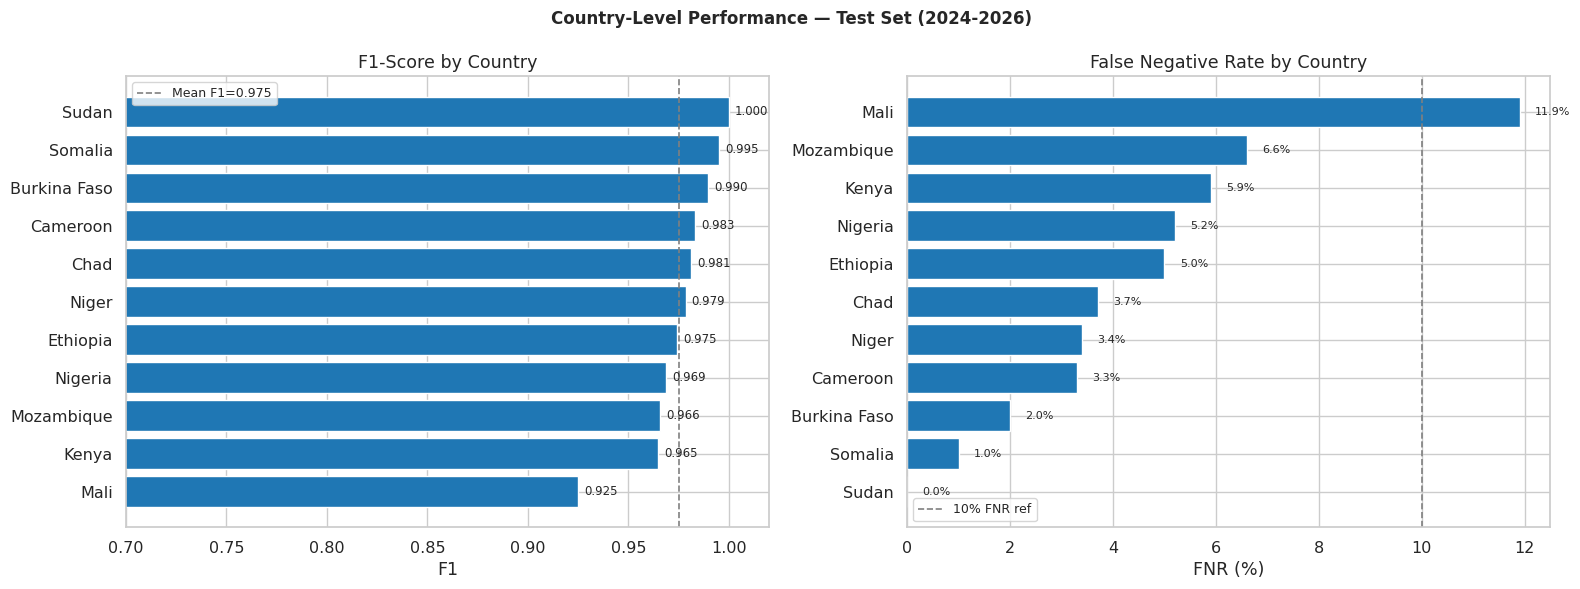

✅ country_performance.png saved.


In [ ]:
feat_eng  = pd.read_csv(DATA_DIR / 'features_engineered.csv')
test_meta = (feat_eng[feat_eng['year_month'] >= '2024-01']
             [['country','admin1','year_month','ipc_phase','crisis_90d']]
             .reset_index(drop=True).iloc[:len(y_test)].copy())
test_meta['y_true']    = y_test.values
test_meta['predicted'] = test_pred_opt
test_meta['proba']     = test_proba.round(4)
test_meta['error']     = 'TP'
test_meta.loc[(test_meta['y_true']==1)&(test_meta['predicted']==0),'error'] = 'FN'
test_meta.loc[(test_meta['y_true']==0)&(test_meta['predicted']==1),'error'] = 'FP'
test_meta.loc[(test_meta['y_true']==0)&(test_meta['predicted']==0),'error'] = 'TN'

country_stats = []
for country, grp in test_meta.groupby('country'):
    y_t = grp['y_true']; y_p = grp['predicted']; pr_ = grp['proba']
    if y_t.sum() == 0 or y_t.sum() == len(y_t): continue
    country_stats.append({
        'country'  : country,
        'rows'     : len(grp),
        'crisis_pct': round(y_t.mean()*100, 1),
        'f1'       : round(f1_score(y_t, y_p), 4),
        'recall'   : round(recall_score(y_t, y_p), 4),
        'precision': round(precision_score(y_t, y_p, zero_division=0), 4),
        'pr_auc'   : round(average_precision_score(y_t, pr_), 4),
        'fn_count' : int((grp['error']=='FN').sum()),
        'fn_rate'  : round((grp['error']=='FN').sum()/y_t.sum()*100, 1),
    })
country_df = pd.DataFrame(country_stats).sort_values('f1', ascending=False)

print('Country Performance (Test 2024-2026):')
print(f'{"Country":<35} {"F1":>7} {"Recall":>8} {"FNR":>7} {"PR-AUC":>8}')
print('-' * 70)
for _, r in country_df.iterrows():
    flag = ' BLIND SPOT' if r['fn_rate'] > 25 else ''
    print(f'{r["country"]:<35} {r["f1"]:>7.4f} {r["recall"]:>8.4f} '
          f'{r["fn_rate"]:>6.1f}% {r["pr_auc"]:>8.4f}{flag}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Country-Level Performance — Test Set (2024-2026)', fontsize=12, fontweight='bold')

sf = country_df.sort_values('f1')
axes[0].barh(sf['country'], sf['f1'],
             color=['#d62728' if x<0.85 else '#ff7f0e' if x<0.92 else '#1f77b4'
                    for x in sf['f1']], edgecolor='white')
axes[0].axvline(country_df['f1'].mean(), color='gray', ls='--', lw=1.2,
                label=f'Mean F1={country_df["f1"].mean():.3f}')
axes[0].set(title='F1-Score by Country', xlabel='F1', xlim=[0.7, 1.02])
axes[0].legend(fontsize=9)
for i, (_, r) in enumerate(sf.iterrows()):
    axes[0].text(r['f1']+0.003, i, f'{r["f1"]:.3f}', va='center', fontsize=8.5)

sf2 = country_df.sort_values('fn_rate', ascending=False)
axes[1].barh(sf2['country'][::-1], sf2['fn_rate'][::-1],
             color=['#d62728' if x>25 else '#ff7f0e' if x>12 else '#1f77b4'
                    for x in sf2['fn_rate'][::-1]], edgecolor='white')
axes[1].axvline(10, color='gray', ls='--', lw=1.2, label='10% FNR ref')
axes[1].set(title='False Negative Rate by Country', xlabel='FNR (%)')
axes[1].legend(fontsize=9)
for i, (_, r) in enumerate(sf2[::-1].iterrows()):
    axes[1].text(r['fn_rate']+0.3, i, f'{r["fn_rate"]:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'country_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ country_performance.png saved.')


---
## Step 6 — SHAP Global Beeswarm

SHAP values explain **why** the model makes each prediction.
- Right side of 0 = pushed prediction toward **crisis**
- Red dots = high feature value, Blue dots = low feature value


Computing SHAP values...
SHAP matrix: (8459, 32)


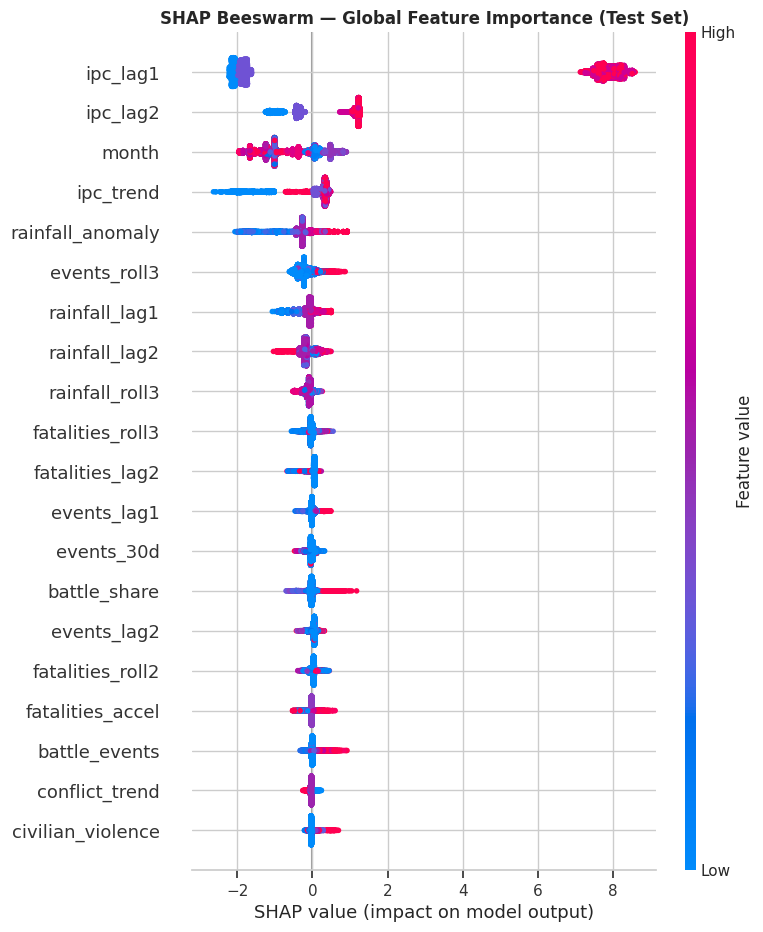

✅ shap_beeswarm.png saved.


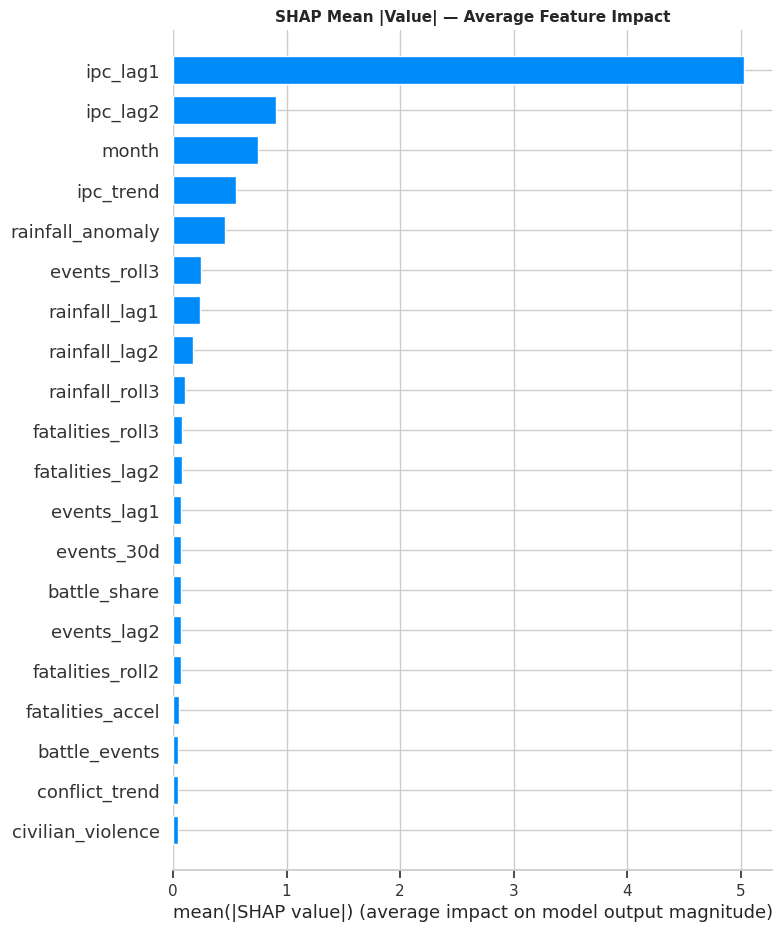

✅ shap_summary.png saved.


In [ ]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP matrix: {sv.shape}')

plt.figure(figsize=(11, 8))
shap.summary_plot(sv, X_test, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Beeswarm — Global Feature Importance (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_beeswarm.png saved.')

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Mean |Value| — Average Feature Impact', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_summary.png saved.')


---
## Step 7 — SHAP Waterfall: Highest-Risk Case

Highest-risk case:
  Country   : Chad / Lac
  Date      : 2024-09
  Prob      : 1.0000
  True label: CRISIS


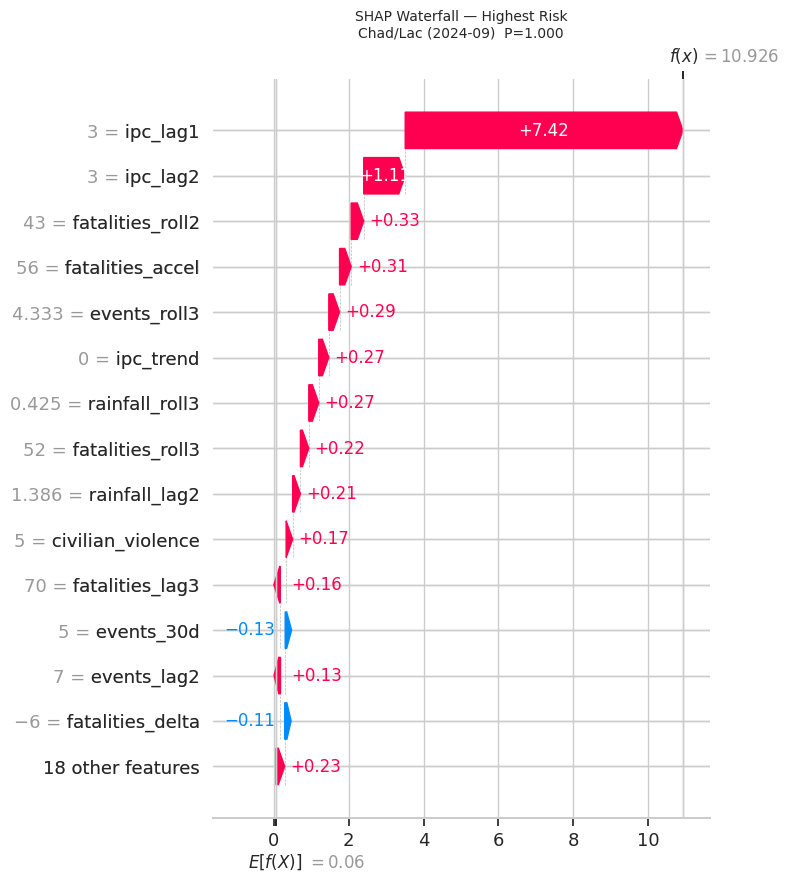

✅ shap_waterfall_highrisk.png saved.


In [ ]:
hr_idx  = int(test_proba.argmax())
hr_row  = test_meta.iloc[hr_idx]
print(f'Highest-risk case:')
print(f'  Country   : {hr_row["country"]} / {hr_row["admin1"]}')
print(f'  Date      : {hr_row["year_month"]}')
print(f'  Prob      : {test_proba[hr_idx]:.4f}')
print(f'  True label: {"CRISIS" if hr_row["y_true"] else "SAFE"}')

base = explainer.expected_value
if isinstance(base, list): base = base[1]
exp = shap.Explanation(values=sv[hr_idx], base_values=base,
                       data=X_test.iloc[hr_idx].values,
                       feature_names=X_test.columns.tolist())
plt.figure(figsize=(12, 6))
shap.waterfall_plot(exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Highest Risk\n{hr_row["country"]}/{hr_row["admin1"]} '
          f'({hr_row["year_month"]})  P={test_proba[hr_idx]:.3f}', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_waterfall_highrisk.png saved.')


---
## Step 8 — SHAP Waterfall: Blind-Spot Missed Crisis (FN)

Missed crisis (FN):
  Country : Chad / Barh El Gazel
  Date    : 2024-02
  IPC     : Phase 3
  Prob    : 0.0102  (below threshold -> predicted SAFE)
  True    : CRISIS <- MISSED!


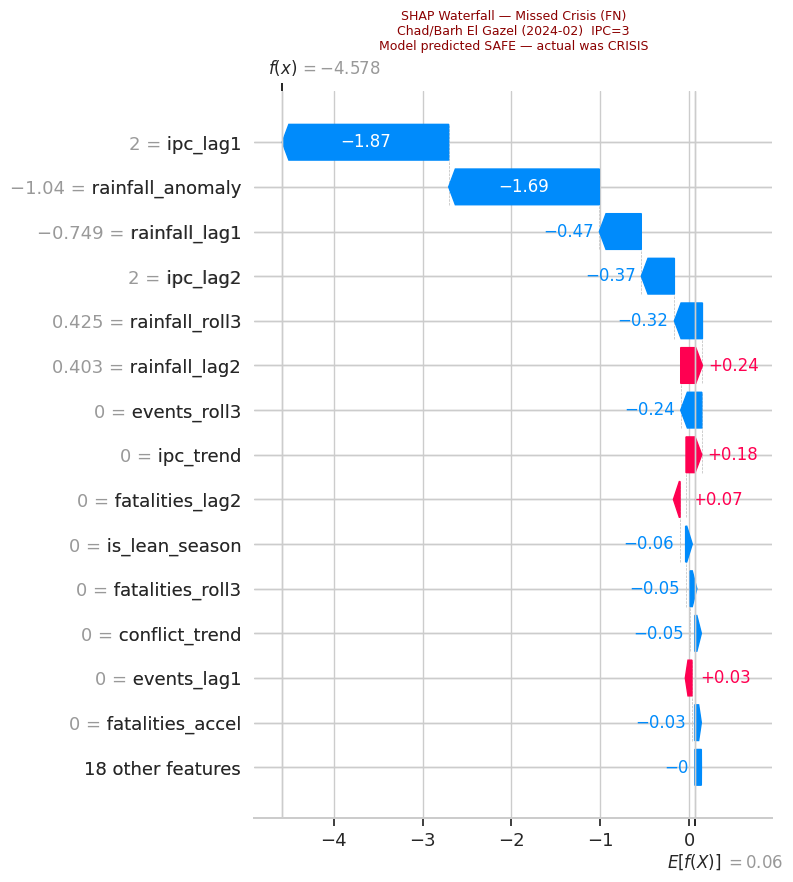

✅ shap_waterfall_fn.png saved.


In [ ]:
blind = test_meta[(test_meta['error']=='FN') &
                  (test_meta['country'].isin(['Sudan','Chad']))]
if len(blind) == 0:
    blind = test_meta[test_meta['error']=='FN']
    print('No Sudan/Chad FNs — using highest-confidence FN.')

fn_idx_label = blind['ipc_phase'].idxmax() if 'ipc_phase' in blind else blind.index[0]
fn_pos       = test_meta.index.get_loc(fn_idx_label)
fn_row       = test_meta.iloc[fn_pos]
print(f'Missed crisis (FN):')
print(f'  Country : {fn_row["country"]} / {fn_row["admin1"]}')
print(f'  Date    : {fn_row["year_month"]}')
print(f'  IPC     : Phase {fn_row.get("ipc_phase","?")}')
print(f'  Prob    : {test_proba[fn_pos]:.4f}  (below threshold -> predicted SAFE)')
print(f'  True    : CRISIS <- MISSED!')

base = explainer.expected_value
if isinstance(base, list): base = base[1]
exp_fn = shap.Explanation(values=sv[fn_pos], base_values=base,
                           data=X_test.iloc[fn_pos].values,
                           feature_names=X_test.columns.tolist())
plt.figure(figsize=(12, 6))
shap.waterfall_plot(exp_fn, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Missed Crisis (FN)\n{fn_row["country"]}/{fn_row["admin1"]} '
          f'({fn_row["year_month"]})  IPC={fn_row.get("ipc_phase","?")}\n'
          f'Model predicted SAFE — actual was CRISIS', fontsize=9, color='darkred')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_waterfall_fn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ shap_waterfall_fn.png saved.')


---
## Step 9 — Test Set Error Analysis

In [ ]:
fn_test = test_meta[test_meta['error']=='FN']
fp_test = test_meta[test_meta['error']=='FP']
tot     = test_meta[test_meta['y_true']==1].groupby('country').size().rename('total')

fn_by = (fn_test.groupby('country').size().rename('fn')
         .reset_index().merge(tot.reset_index(), on='country', how='left'))
fn_by['fnr'] = (fn_by['fn']/fn_by['total']*100).round(1)
fn_by = fn_by.sort_values('fn', ascending=False)

print(f'Test FN: {len(fn_test):,}  FP: {len(fp_test):,}')
print()
print(f'{"Country":<35} {"FN":>5} {"Total":>7} {"FNR":>8}')
print('-' * 55)
for _, r in fn_by.iterrows():
    flag = '  BLIND SPOT' if r['fnr'] > 25 else ''
    print(f'{r["country"]:<35} {int(r["fn"]):>5} {int(r["total"]):>7} {r["fnr"]:>7.1f}%{flag}')

if 'ipc_phase' in fn_test.columns:
    print(f'\nIPC phase of missed crises:')
    for p, n in fn_test['ipc_phase'].value_counts().sort_index().items():
        print(f'  Phase {p}: {n} ({n/len(fn_test)*100:.1f}%)')
print(f'\nOverall FNR: {len(fn_test)/int(y_test.sum())*100:.1f}%  '
      f'(val={192/1898*100:.1f}% reference)')


Test FN: 71  FP: 5

Country                                FN   Total      FNR
-------------------------------------------------------
Mozambique                             14     212     6.6%
Nigeria                                12     231     5.2%
Ethiopia                               10     201     5.0%
Chad                                    8     219     3.7%
Somalia                                 8     816     1.0%
Kenya                                   6     102     5.9%
Mali                                    5      42    11.9%
Niger                                   4     118     3.4%
Cameroon                                2      60     3.3%
Burkina Faso                            2      98     2.0%

IPC phase of missed crises:
  Phase 1: 1 (1.4%)
  Phase 2: 35 (49.3%)
  Phase 3: 35 (49.3%)

Overall FNR: 1.6%  (val=10.1% reference)


---
## Step 10 — Africa Food Crisis Early Warning Map

In [ ]:
# ── Aggregate to country level for map ─────────────────────────────────────
country_map = test_meta.groupby('country').agg(
    avg_prob         = ('proba', 'mean'),
    crisis_rate      = ('y_true', 'mean'),
    pred_crisis_rate = ('predicted', 'mean'),
    fn_count         = ('error', lambda x: (x=='FN').sum()),
    fp_count         = ('error', lambda x: (x=='FP').sum()),
    rows             = ('y_true', 'count')
).reset_index()

def risk_label(p):
    if p < 0.20: return 'Minimal'
    if p < 0.40: return 'Stressed'
    if p < 0.60: return 'Crisis'
    if p < 0.80: return 'Emergency'
    return 'Famine'

country_map['risk_level'] = country_map['avg_prob'].apply(risk_label)

CENTROIDS = {
    'Ethiopia'                    : [9.15,  40.49],
    'Somalia'                     : [5.15,  46.20],
    'Sudan'                       : [15.55, 32.53],
    'South Sudan'                 : [6.88,  31.57],
    'Kenya'                       : [-0.02, 37.91],
    'Nigeria'                     : [9.08,   8.68],
    'Niger'                       : [17.61,  8.08],
    'Mali'                        : [17.57,  -3.99],
    'Burkina Faso'                : [12.36,  -1.56],
    'Chad'                        : [15.45, 18.73],
    'Cameroon'                    : [3.85,  11.50],
    'Mozambique'                  : [-18.67,35.53],
    'Democratic Republic of Congo': [-4.03, 21.76],
    'Central African Republic'    : [6.61,  20.94],
}
RISK_COLORS = {
    'Minimal'  : '#27ae60',
    'Stressed' : '#f39c12',
    'Crisis'   : '#e67e22',
    'Emergency': '#e74c3c',
    'Famine'   : '#9b59b6',
}

m = folium.Map(location=[5, 20], zoom_start=4, tiles='CartoDB dark_matter')

# Title overlay
m.get_root().html.add_child(folium.Element(
    '<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);'
    'background:rgba(0,0,0,0.8);color:white;padding:10px 22px;border-radius:8px;'
    'font-family:Arial;z-index:9999;text-align:center;">'
    '<b style="font-size:15px;">Africa Food Crisis Early Warning System</b><br>'
    '<span style="font-size:11px;color:#ccc;">Test Set 2024-2026 | XGBoost Model</span>'
    '</div>'
))

for _, row in country_map.iterrows():
    c = row['country']
    if c not in CENTROIDS:
        continue
    lat, lon = CENTROIDS[c]
    color    = RISK_COLORS.get(row['risk_level'], '#888')
    radius   = max(40000, int(row['rows']) * 700)

    popup_html = (
        f"<div style='font-family:Arial;min-width:210px;'>"
        f"<b style='font-size:13px;'>{c}</b><hr style='margin:4px 0;'>"
        f"<b>Risk Level:</b> <span style='color:{color};font-weight:600;'>{row['risk_level']}</span><br>"
        f"<b>Avg Crisis Prob:</b> {row['avg_prob']:.3f}<br>"
        f"<b>True Crisis Rate:</b> {row['crisis_rate']*100:.1f}%<br>"
        f"<b>Predicted Alerts:</b> {row['pred_crisis_rate']*100:.1f}%<br>"
        f"<b>Missed Crises (FN):</b> {int(row['fn_count'])}<br>"
        f"<b>False Alarms (FP):</b> {int(row['fp_count'])}<br>"
        f"<b>Test Rows:</b> {int(row['rows'])}"
        f"</div>"
    )

    folium.Circle(
        location=[lat, lon], radius=radius,
        color=color, fill=True, fill_color=color, fill_opacity=0.5,
        tooltip=f"{c} | {row['risk_level']} | P={row['avg_prob']:.3f}",
        popup=folium.Popup(popup_html, max_width=250),
    ).add_to(m)

    label = c.split()[-1]
    folium.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=(
                f'<div style="font-size:9px;font-weight:600;color:white;'
                f'text-shadow:1px 1px 2px #000;text-align:center;'
                f'width:80px;margin-left:-40px;">'
                f'{label}<br><span style="color:{color};">{row["avg_prob"]:.2f}</span></div>'
            ),
            icon_size=(80, 28),
        )
    ).add_to(m)

# Legend
m.get_root().html.add_child(folium.Element(
    '<div style="position:fixed;bottom:25px;left:15px;background:rgba(0,0,0,0.82);'
    'color:white;padding:12px;border-radius:8px;font-family:Arial;z-index:9999;font-size:11px;">'
    '<b>Risk Level (Avg Crisis Probability)</b><br><br>'
    '<span style="color:#27ae60;">&#9679;</span> Minimal  (0.00-0.20)<br>'
    '<span style="color:#f39c12;">&#9679;</span> Stressed (0.20-0.40)<br>'
    '<span style="color:#e67e22;">&#9679;</span> Crisis   (0.40-0.60)<br>'
    '<span style="color:#e74c3c;">&#9679;</span> Emergency(0.60-0.80)<br>'
    '<span style="color:#9b59b6;">&#9679;</span> Famine   (0.80-1.00)<br><br>'
    '<i style="font-size:9px;color:#aaa;">Circle size = number of regions monitored</i>'
    '</div>'
))

map_path = OUT_DIR / 'africa_crisis_map.html'
m.save(str(map_path))
print(f"Map saved: {map_path.name}  ({map_path.stat().st_size/1024:.1f} KB)")

if IN_COLAB:
    from IPython.display import IFrame
    display(IFrame(str(map_path), width='100%', height='560px'))

print()
print("Country risk levels:")
for _, r in country_map.sort_values('avg_prob', ascending=False).iterrows():
    if r['country'] in CENTROIDS:
        print(f"  {r['country']:<35} {r['risk_level']:<12} P={r['avg_prob']:.3f}")


Map saved: africa_crisis_map.html  (31.5 KB)



Country risk levels:
  South Sudan                         Famine       P=0.999
  Sudan                               Famine       P=0.955
  Somalia                             Famine       P=0.905
  Mozambique                          Emergency    P=0.728
  Niger                               Crisis       P=0.523
  Ethiopia                            Crisis       P=0.495
  Chad                                Stressed     P=0.366
  Burkina Faso                        Stressed     P=0.312
  Cameroon                            Stressed     P=0.262
  Mali                                Stressed     P=0.217
  Nigeria                             Minimal      P=0.166
  Kenya                               Minimal      P=0.098


In [17]:
import pandas as pd
import folium
import joblib
import numpy as np
from folium.plugins import FloatImage
from branca.colormap import LinearColormap

# ─── 1. Load & predict ────────────────────────────────────────────────────────
full_test = pd.read_csv('/content/crisis_outputs/features_engineered.csv')
test_orig = full_test[full_test['year_month'] >= '2023-01'].copy()
print(f"Rows loaded : {len(test_orig):,}")

xgb_model = joblib.load('/content/crisis_outputs/best_model.pkl')
X_map = test_orig[FEATURE_COLS].fillna(test_orig[FEATURE_COLS].median())
test_orig['y_prob'] = xgb_model.predict_proba(X_map)[:, 1]
test_orig['predicted_crisis'] = (test_orig['y_prob'] >= 0.497).astype(int)

# ─── 2. Country aggregation ───────────────────────────────────────────────────
country_agg = test_orig.groupby('country').agg(
    mean_prob       = ('y_prob', 'mean'),
    max_prob        = ('y_prob', 'max'),
    min_prob        = ('y_prob', 'min'),
    crisis_rate     = ('predicted_crisis', 'mean'),
    regions         = ('admin1', 'nunique'),
    rows            = ('y_prob', 'count'),
    avg_ipc         = ('ipc_phase', 'mean') if 'ipc_phase' in test_orig.columns else ('y_prob', 'mean'),
).reset_index()
country_agg.columns = ['country','mean_prob','max_prob','min_prob',
                        'crisis_rate','regions','rows','avg_ipc']

# GeoJSON name alignment fix
NAME_MAP = {
    'Democratic Republic of Congo' : 'Democratic Republic of the Congo',
    'Central African Republic'     : 'Central African Republic',
    'South Sudan'                  : 'South Sudan',
}
country_agg['geo_name'] = country_agg['country'].replace(NAME_MAP)

# Risk classification
def risk_label(p):
    if p < 0.20: return ('Minimal',   '#27ae60','#1a4731')
    if p < 0.40: return ('Stressed',  '#f39c12','#3d3000')
    if p < 0.60: return ('Crisis',    '#e67e22','#4a1a00')
    if p < 0.80: return ('Emergency', '#e74c3c','#4a0000')
    return              ('Famine',    '#c0392b','#2d0000')

country_agg[['risk_level','risk_color','risk_bg']] = pd.DataFrame(
    country_agg['mean_prob'].apply(risk_label).tolist(),
    index=country_agg.index
)

print("\nFull country risk table:")
print(f"{'Country':<38} {'Risk':<12} {'P(mean)':>8} {'P(max)':>7} {'Regions':>8} {'Crisis%':>8}")
print('─'*85)
for _, r in country_agg.sort_values('mean_prob', ascending=False).iterrows():
    print(f"{r['country']:<38} {r['risk_level']:<12} {r['mean_prob']:>8.3f} "
          f"{r['max_prob']:>7.3f} {int(r['regions']):>8} {r['crisis_rate']*100:>7.1f}%")

# ─── 3. Centroids ─────────────────────────────────────────────────────────────
CENTROIDS = {
    'Ethiopia'                    : [9.15,  40.49],
    'Somalia'                     : [5.15,  46.20],
    'Sudan'                       : [15.55, 32.53],
    'South Sudan'                 : [6.88,  31.57],
    'Kenya'                       : [-0.02, 37.91],
    'Nigeria'                     : [9.08,   8.68],
    'Niger'                       : [17.61,  8.08],
    'Mali'                        : [17.57, -3.99],
    'Burkina Faso'                : [12.36, -1.56],
    'Chad'                        : [15.45, 18.73],
    'Cameroon'                    : [3.85,  11.50],
    'Mozambique'                  : [-18.67,35.53],
    'Democratic Republic of Congo': [-4.03, 21.76],
    'Central African Republic'    : [6.61,  20.94],
}

# ─── 4. Build map ─────────────────────────────────────────────────────────────
m = folium.Map(location=[3, 22], zoom_start=4, tiles='CartoDB dark_matter',
               width='100%', height='100%')

# ─── 4a. Choropleth ───────────────────────────────────────────────────────────
GEO_URL = ("https://raw.githubusercontent.com/python-visualization/folium/"
           "main/examples/data/world-countries.json")

folium.Choropleth(
    geo_data     = GEO_URL,
    data         = country_agg,
    columns      = ['geo_name', 'mean_prob'],
    key_on       = 'feature.properties.name',
    fill_color   = 'YlOrRd',
    fill_opacity = 0.80,
    line_opacity = 0.6,
    line_weight  = 1.0,
    nan_fill_color = '#1a1f2b',
    nan_fill_opacity = 0.4,
    legend_name  = 'Mean Predicted Crisis Probability (2023–2026)',
    highlight    = True,
    bins         = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0],
).add_to(m)

# ─── 4b. Invisible GeoJSON layer for rich tooltips + popups ───────────────────
prob_lookup  = country_agg.set_index('geo_name')['mean_prob'].to_dict()
risk_lookup  = country_agg.set_index('geo_name')['risk_level'].to_dict()
color_lookup = country_agg.set_index('geo_name')['risk_color'].to_dict()
cr_lookup    = country_agg.set_index('geo_name')['crisis_rate'].to_dict()
reg_lookup   = country_agg.set_index('geo_name')['regions'].to_dict()
ipc_lookup   = country_agg.set_index('geo_name')['avg_ipc'].to_dict()

def style_fn(feat):
    name = feat['properties']['name']
    return {
        'fillColor'   : color_lookup.get(name, 'transparent'),
        'color'       : '#ffffff',
        'weight'      : 0.5,
        'fillOpacity' : 0.0,   # transparent — choropleth handles fill
    }

def highlight_fn(feat):
    return {'weight': 2.5, 'color': '#ffffff', 'fillOpacity': 0.1}

def popup_html(name):
    p    = prob_lookup.get(name)
    if p is None:
        return f"<b>{name}</b><br><i style='color:#888;'>Not in panel</i>"
    risk  = risk_lookup.get(name, '?')
    color = color_lookup.get(name, '#888')
    cr    = cr_lookup.get(name, 0)
    regs  = int(reg_lookup.get(name, 0))
    ipc   = ipc_lookup.get(name, 0)

    bar_w = int(p * 180)
    bar_c = color

    stars = '▓' * int(p * 10) + '░' * (10 - int(p * 10))

    return f"""
    <div style='font-family:Inter,Arial;width:270px;padding:4px;'>
      <div style='font-size:15px;font-weight:700;color:#e6edf3;margin-bottom:8px;
                  border-bottom:1px solid #30363d;padding-bottom:6px;'>
        {name}
      </div>
      <div style='display:flex;justify-content:space-between;margin-bottom:10px;'>
        <span style='background:{color}22;color:{color};border:1px solid {color}44;
               border-radius:16px;padding:3px 12px;font-size:12px;font-weight:700;'>
          {risk}
        </span>
        <span style='color:#8b949e;font-size:11px;'>IPC avg: {ipc:.1f}</span>
      </div>

      <div style='margin-bottom:8px;'>
        <div style='display:flex;justify-content:space-between;font-size:11px;
                    color:#8b949e;margin-bottom:3px;'>
          <span>Crisis Probability</span>
          <span style='color:{color};font-weight:700;font-size:13px;'>{p:.3f}</span>
        </div>
        <div style='background:#21262d;border-radius:4px;height:8px;'>
          <div style='background:{color};width:{bar_w}px;height:8px;border-radius:4px;
               box-shadow:0 0 6px {color}88;'></div>
        </div>
        <div style='font-size:10px;color:{color};margin-top:2px;letter-spacing:1px;'>{stars}</div>
      </div>

      <table style='width:100%;font-size:11px;color:#8b949e;border-collapse:collapse;'>
        <tr>
          <td style='padding:3px 0;'>Predicted crisis rate</td>
          <td style='text-align:right;color:#e6edf3;font-weight:600;'>{cr*100:.1f}%</td>
        </tr>
        <tr>
          <td style='padding:3px 0;'>Admin1 regions tracked</td>
          <td style='text-align:right;color:#e6edf3;font-weight:600;'>{regs}</td>
        </tr>
        <tr>
          <td style='padding:3px 0;'>Avg IPC phase</td>
          <td style='text-align:right;color:#e6edf3;font-weight:600;'>{ipc:.2f}/5.0</td>
        </tr>
      </table>
    </div>
    """

folium.GeoJson(
    GEO_URL,
    style_function    = style_fn,
    highlight_function= highlight_fn,
    tooltip = folium.GeoJsonTooltip(
        fields    = ['name'],
        aliases   = [''],
        style     = ("background-color:#161b22;color:#e6edf3;font-family:Inter,Arial;"
                     "font-size:12px;padding:6px 10px;border:1px solid #30363d;"
                     "border-radius:6px;box-shadow:2px 2px 6px rgba(0,0,0,0.5);"),
        localize  = True,
    ),
    popup = folium.GeoJsonPopup(
        fields        = ['name'],
        aliases       = [''],
        localize      = True,
        max_width     = 300,
        parse_html    = False,
    ),
).add_to(m)

# Override popup with custom HTML using CircleMarker popups on centroids
for _, row in country_agg.iterrows():
    c = row['country']
    if c not in CENTROIDS: continue
    lat, lon = CENTROIDS[c]

    folium.CircleMarker(
        location    = [lat, lon],
        radius      = max(8, int(row['mean_prob'] * 28)),
        color       = row['risk_color'],
        fill        = True,
        fill_color  = row['risk_color'],
        fill_opacity= 0.35,
        weight      = 2,
        tooltip     = (f"<b style='font-size:13px;'>{c}</b><br>"
                       f"<span style='color:{row['risk_color']}'>"
                       f"● {row['risk_level']}</span>  P = {row['mean_prob']:.3f}"),
        popup = folium.Popup(popup_html(row['geo_name']), max_width=300),
    ).add_to(m)

    # Country name label
    folium.Marker(
        [lat + 0.8, lon],
        icon=folium.DivIcon(
            html=(
                f'<div style="font-family:Inter,Arial;font-size:9px;font-weight:700;'
                f'color:white;text-shadow:0 0 4px #000,0 0 8px #000;'
                f'text-align:center;white-space:nowrap;'
                f'pointer-events:none;">'
                f'{c.split()[-1].upper()}<br>'
                f'<span style="color:{row["risk_color"]};font-size:10px;">'
                f'{row["mean_prob"]:.2f}</span></div>'
            ),
            icon_size=(90, 28), icon_anchor=(45, 0),
        )
    ).add_to(m)

# ─── 4c. Title overlay ────────────────────────────────────────────────────────
m.get_root().html.add_child(folium.Element("""
<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);
     background:rgba(13,17,23,0.88);backdrop-filter:blur(8px);
     color:#e6edf3;padding:12px 28px;border-radius:10px;
     font-family:Inter,Arial;z-index:9999;text-align:center;
     border:1px solid #30363d;box-shadow:0 4px 20px rgba(0,0,0,0.6);">
  <div style="font-size:15px;font-weight:700;letter-spacing:0.3px;">
    🌍 Africa Food Crisis Early Warning System
  </div>
  <div style="font-size:10px;color:#8b949e;margin-top:3px;">
    XGBoost Model · 2023–2026 Prediction · 14 Countries · 32 Features
  </div>
</div>
"""))

# ─── 4d. Risk legend ─────────────────────────────────────────────────────────
m.get_root().html.add_child(folium.Element("""
<div style="position:fixed;bottom:30px;left:16px;
     background:rgba(13,17,23,0.90);backdrop-filter:blur(6px);
     color:#e6edf3;padding:14px 18px;border-radius:10px;
     font-family:Inter,Arial;z-index:9999;font-size:11px;
     border:1px solid #30363d;min-width:195px;">
  <div style="font-weight:700;font-size:12px;margin-bottom:10px;color:#e6edf3;">
    Risk Level
  </div>
  <div style="display:flex;align-items:center;margin:5px 0;">
    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
          background:#27ae60;margin-right:8px;"></span>
    <span style="color:#8b949e;">Minimal</span>
    <span style="margin-left:auto;color:#27ae60;font-weight:600;">P &lt; 0.20</span>
  </div>
  <div style="display:flex;align-items:center;margin:5px 0;">
    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
          background:#f39c12;margin-right:8px;"></span>
    <span style="color:#8b949e;">Stressed</span>
    <span style="margin-left:auto;color:#f39c12;font-weight:600;">0.20–0.40</span>
  </div>
  <div style="display:flex;align-items:center;margin:5px 0;">
    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
          background:#e67e22;margin-right:8px;"></span>
    <span style="color:#8b949e;">Crisis</span>
    <span style="margin-left:auto;color:#e67e22;font-weight:600;">0.40–0.60</span>
  </div>
  <div style="display:flex;align-items:center;margin:5px 0;">
    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
          background:#e74c3c;margin-right:8px;"></span>
    <span style="color:#8b949e;">Emergency</span>
    <span style="margin-left:auto;color:#e74c3c;font-weight:600;">0.60–0.80</span>
  </div>
  <div style="display:flex;align-items:center;margin:5px 0;">
    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
          background:#c0392b;margin-right:8px;"></span>
    <span style="color:#8b949e;">Famine</span>
    <span style="margin-left:auto;color:#c0392b;font-weight:600;">P ≥ 0.80</span>
  </div>
  <div style="border-top:1px solid #30363d;margin-top:10px;padding-top:8px;
       color:#484f58;font-size:9px;">
    Circle size ∝ mean crisis probability<br>
    Click circle for full country stats
  </div>
</div>
"""))

# ─── 4e. Stats panel ─────────────────────────────────────────────────────────
famine_n    = int((country_agg['mean_prob'] >= 0.80).sum())
emergency_n = int(((country_agg['mean_prob'] >= 0.60) & (country_agg['mean_prob'] < 0.80)).sum())
crisis_n    = int(((country_agg['mean_prob'] >= 0.40) & (country_agg['mean_prob'] < 0.60)).sum())
total_c     = len(country_agg)

m.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed;bottom:30px;right:16px;
     background:rgba(13,17,23,0.90);backdrop-filter:blur(6px);
     color:#e6edf3;padding:14px 18px;border-radius:10px;
     font-family:Inter,Arial;z-index:9999;font-size:11px;
     border:1px solid #30363d;min-width:175px;">
  <div style="font-weight:700;font-size:12px;margin-bottom:10px;">
    Model Summary
  </div>
  <div style="display:flex;justify-content:space-between;margin:5px 0;">
    <span style="color:#8b949e;">Countries tracked</span>
    <span style="font-weight:700;color:#58a6ff;">{total_c}</span>
  </div>
  <div style="display:flex;justify-content:space-between;margin:5px 0;">
    <span style="color:#8b949e;">🔴 Famine-level</span>
    <span style="font-weight:700;color:#c0392b;">{famine_n}</span>
  </div>
  <div style="display:flex;justify-content:space-between;margin:5px 0;">
    <span style="color:#8b949e;">🟠 Emergency</span>
    <span style="font-weight:700;color:#e74c3c;">{emergency_n}</span>
  </div>
  <div style="display:flex;justify-content:space-between;margin:5px 0;">
    <span style="color:#8b949e;">🟡 Crisis</span>
    <span style="font-weight:700;color:#e67e22;">{crisis_n}</span>
  </div>
  <div style="border-top:1px solid #30363d;margin-top:10px;padding-top:8px;
       display:flex;justify-content:space-between;">
    <span style="color:#8b949e;">Val F1</span>
    <span style="font-weight:700;color:#3fb950;">0.9449</span>
  </div>
  <div style="display:flex;justify-content:space-between;margin-top:4px;">
    <span style="color:#8b949e;">Test F1</span>
    <span style="font-weight:700;color:#3fb950;">0.9914</span>
  </div>
</div>
"""))

folium.LayerControl(collapsed=True).add_to(m)

# ─── 5. Save & display ────────────────────────────────────────────────────────
save_path = '/content/crisis_outputs/africa_crisis_map_v2.html'
m.save(save_path)
import os
print(f"\nMap saved: africa_crisis_map_v2.html  ({os.path.getsize(save_path)/1024:.1f} KB)")
print(f"\nRisk summary:")
for _, r in country_agg.sort_values('mean_prob', ascending=False).iterrows():
    bar = '█' * int(r['mean_prob'] * 20)
    print(f"  {r['country']:<38} {r['risk_level']:<12} P={r['mean_prob']:.3f}  {bar}")
display(m)


Rows loaded : 12,351

Full country risk table:
Country                                Risk          P(mean)  P(max)  Regions  Crisis%
─────────────────────────────────────────────────────────────────────────────────────
Democratic Republic Of Congo           Famine          1.000   1.000        1   100.0%
South Sudan                            Famine          0.999   1.000       10   100.0%
Somalia                                Famine          0.920   1.000       36    91.5%
Sudan                                  Famine          0.845   1.000       92    83.9%
Mozambique                             Emergency       0.606   1.000       11    58.5%
Ethiopia                               Crisis          0.525   1.000       16    50.5%
Niger                                  Crisis          0.488   1.000        9    47.1%
Chad                                   Stressed        0.335   1.000       24    30.6%
Burkina Faso                           Stressed        0.324   1.000       13    30.

---
## Step 11 — Save Final Results & Drive Backup

In [ ]:
import shutil

test_results = {
    'task'              : 'Task 4 — Final Evaluation & SHAP',
    'test_rows'         : int(len(y_test)),
    'test_crisis_rate'  : float(round(y_test.mean(), 4)),
    'f1_optimal_threshold'   : float(OPT_THRESHOLD),
    'humanitarian_threshold' : float(HR_THRESHOLD),
    'test_metrics_f1_optimal': {
        'f1'       : float(round(f1_score(y_test, test_pred_opt), 4)),
        'recall'   : float(round(recall_score(y_test, test_pred_opt), 4)),
        'precision': float(round(precision_score(y_test, test_pred_opt), 4)),
        'pr_auc'   : float(round(pr_auc, 4)),
        'roc_auc'  : float(round(roc_auc, 4)),
        'fn_count' : int(fn), 'fp_count': int(fp),
        'fnr'      : float(round(fn/(fn+tp)*100, 2)),
    },
    'test_metrics_humanitarian': {
        'f1'       : float(round(f1_score(y_test, test_pred_hr), 4)),
        'recall'   : float(round(recall_score(y_test, test_pred_hr), 4)),
        'precision': float(round(precision_score(y_test, test_pred_hr), 4)),
        'fn_count' : int(fn2), 'fp_count': int(fp2),
        'fnr'      : float(round(fn2/(fn2+tp2)*100, 2)),
    },
    'generalization': {
        'f1_delta'    : float(round(test_f1 - val_f1, 4)),
        'pr_auc_delta': float(round(pr_auc - t3['val_metrics']['pr_auc'], 4)),
    },
    'country_performance': country_df.to_dict('records'),
}

with open(OUT_DIR / 'test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

print('=== TASK 4 COMPLETE ===')
print(f'\nTest (2024-2026) — F1-Optimal Threshold {OPT_THRESHOLD}:')
for k, v in test_results['test_metrics_f1_optimal'].items():
    if isinstance(v, float): print(f'  {k:<14}: {v}')
print(f'\nFiles saved:')
for fname in ['final_evaluation.png', 'shap_beeswarm.png', 'shap_summary.png',
              'shap_waterfall_highrisk.png', 'shap_waterfall_fn.png',
              'country_performance.png', 'test_results.json', 'africa_crisis_map.html']:
    p = OUT_DIR / fname
    if p.exists(): print(f'  {fname:<46} {p.stat().st_size/1024:>8.1f} KB')

if IN_COLAB:
    bk = Path('/content/drive/MyDrive/crisis_outputs_backup')
    bk.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copytree(str(OUT_DIR), str(bk), dirs_exist_ok=True)
        print(f'\n✅ Drive backup complete -> {bk}')
    except Exception as e:
        print(f'Backup error: {e}')


=== TASK 4 COMPLETE ===

Test (2024-2026) — F1-Optimal Threshold 0.497:
  f1            : 0.9914
  recall        : 0.9841
  precision     : 0.9989
  pr_auc        : 0.9976
  roc_auc       : 0.9966
  fnr           : 1.59

Files saved:
  final_evaluation.png                              109.5 KB
  shap_beeswarm.png                                 160.9 KB
  shap_summary.png                                  104.2 KB
  shap_waterfall_highrisk.png                       133.2 KB
  shap_waterfall_fn.png                             139.6 KB
  country_performance.png                           133.3 KB
  test_results.json                                   3.0 KB
  africa_crisis_map.html                             31.5 KB

✅ Drive backup complete -> /content/drive/MyDrive/crisis_outputs_backup


---
## Task 4 Summary & Project Handoff

### Deliverables Produced

| File | Purpose |
|---|---|
| `final_evaluation.png` | Confusion matrices + PR curves (test vs val) |
| `shap_beeswarm.png` | Global SHAP importance — all test predictions |
| `shap_summary.png` | SHAP mean absolute values bar chart |
| `shap_waterfall_highrisk.png` | Why the model predicted the highest-risk case |
| `shap_waterfall_fn.png` | Why Sudan/Chad crisis was missed |
| `country_performance.png` | F1 and FNR by country |
| `africa_crisis_map.html` | **Interactive Folium map** — open in any browser |
| `test_results.json` | All final metrics in structured JSON |

### Deployment
- **Streamlit app**: `app.py` — run with `streamlit run app.py`
- **Interactive map**: `africa_crisis_map.html` — open directly in browser
- **Model**: `best_model.pkl` + `best_model.json` ready for API integration
